In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  

from pathlib import Path

OUTPUT = Path('output')

sns.set_theme(style="whitegrid")

## Utils here

In [73]:
def save_fig(name, fig_extension='pdf'):
    path = OUTPUT / f'{name}.{fig_extension}'
    plt.savefig(path, format=fig_extension)


def flat_mean(series):
    n = len(series)

    total = 0
    for x in series:
        total += x
    return total / n


def flat_variance(series):
    n = len(series)
    m = flat_mean(series)

    sq_diff = 0
    for x in series:
        sq_diff += (x - m) ** 2
    return sq_diff / (n - 1)


def expected_val(fi, pmf):
    expected = 0
    for v in range(4):
        expected += fi.iloc[v] * pmf.iloc[v]
    return expected

def variance(fi, pmf, expected):
    var = 0
    for v in range(4):
        var += ((fi.iloc[v] - expected) ** 2) * pmf.iloc[v]
    return var


# Load & Pre-processing

In [74]:
df = pd.read_csv('heart+disease\processed.cleveland.data', header=None,
                 na_values='?')
df.columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

target_columns = ['age', 'sex', 'thalach', 'target']
df = df[target_columns]

df['target'] = (df['target'] > 0).astype(int)

<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\kevin\AppData\Local\Temp\ipykernel_34748\3835045932.py:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  df = pd.read_csv('heart+disease\processed.cleveland.data', header=None,


In [75]:
df.head()

,age,sex,thalach,target
0,63.0,1.0,150.0,0
1,67.0,1.0,108.0,1
2,67.0,1.0,129.0,1
3,37.0,1.0,187.0,0
4,41.0,0.0,172.0,0


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      303 non-null    float64
 1   sex      303 non-null    float64
 2   thalach  303 non-null    float64
 3   target   303 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 9.6 KB


In [77]:
print(df.isnull().sum())

age        0
sex        0
thalach    0
target     0
dtype: int64


In [78]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
target,303.0,0.458746,0.499120,0.0,0.0,0.0,1.0,1.0


# Part One

## Age frequency distribution

In [79]:
max_v = df['age'].max()
min_v = df['age'].min()

amplitude = max_v - min_v

k = 1 + 3.332 * np.log10(56)
k = round(k)

h = amplitude / k
h = round(h)

print(f'amplitude: {amplitude}')
print(f'k:         {k}')
print(f'h:         {h}')

amplitude: 48.0
k:         7
h:         7


In [80]:
intervals = []
start = min_v

for i in range(k):
    end = start + h
    intervals.append((start, end))
    start = end

interval_bastions = []
for i in intervals:
    interval_bastions.append(i[0])
interval_bastions.append(intervals[-1][1])

In [81]:
data = pd.Series(df['age'])

idx = pd.interval_range(start=min_v, end=interval_bastions[-1], periods=k, closed='left')
frequencies_table = pd.DataFrame(index=idx)
df.index

RangeIndex(start=0, stop=303, step=1)

In [82]:
counts = pd.cut(data, bins=interval_bastions, right=False).value_counts().sort_index()
frequencies_table['fi'] = counts.values
frequencies_table['fr'] = frequencies_table['fi'] / df['age'].shape[0]
frequencies_table['fraci'] = frequencies_table['fr'].cumsum()
frequencies_table['pmi'] = [interval.mid for interval in frequencies_table.index]

In [83]:
frequencies_table

,fi,fr,fraci,pmi
"[29.0, 36.0)",7,0.023102,0.023102,32.5
"[36.0, 43.0)",29,0.095710,0.118812,39.5
"[43.0, 50.0)",51,0.168317,0.287129,46.5
"[50.0, 57.0)",75,0.247525,0.534653,53.5
"[57.0, 64.0)",90,0.297030,0.831683,60.5
"[64.0, 71.0)",45,0.148515,0.980198,67.5
"[71.0, 78.0)",6,0.019802,1.000000,74.5


In [84]:
mean = flat_mean(df['age'])
var = flat_variance(df['age'])
std = np.sqrt(var)

print(f'mean: {mean:.4f}'
      f'\nvar:  {var:.4f}'
      f'\nstd:  {std:.4f}')

mean: 54.4389
var:  81.6974
std:  9.0387


# Part Two


Nessa parte temos os gráficos:
1. Heatmap: Permite sabermos as correlações entre as colunas dos nossos dados, quanto mais a correlação se aproxima de 1 mais as colunas se relacionam.
2. Gráfico de correlação entre as variáveis: age e thalach. O gráfico demonstra uma correlação negativa, já que possuem o coeficiente de correlação entre -1 e 0. Isso basicamente demonstra que enquanto uma aumenta a outra diminui ou vice-versa, adicionando o gráfico possui uma relação linear fraca, pois conseguimos perceber a relação negativa, mas, ainda estáo um pouco concentrados os dados  

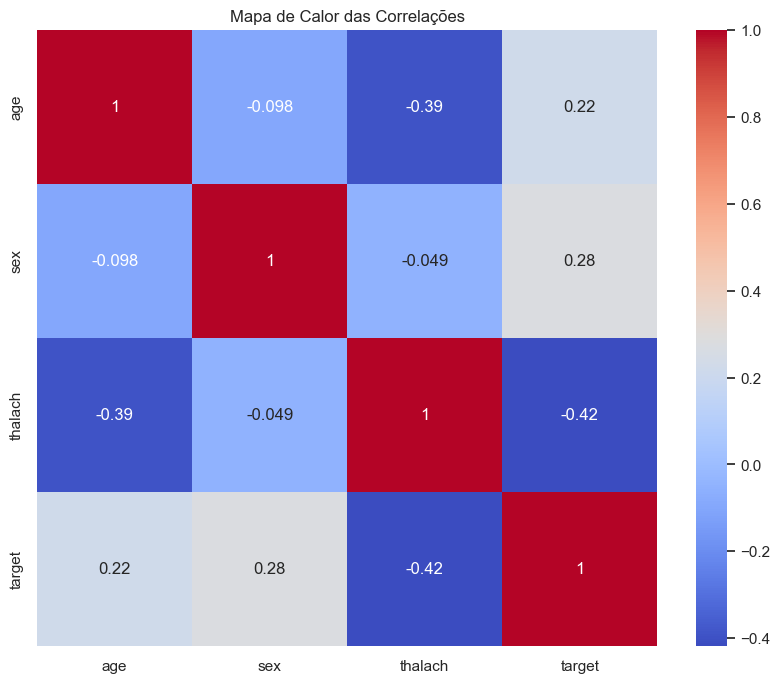

In [85]:
numerical_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm")
plt.title("Mapa de Calor das Correlações")
plt.show()

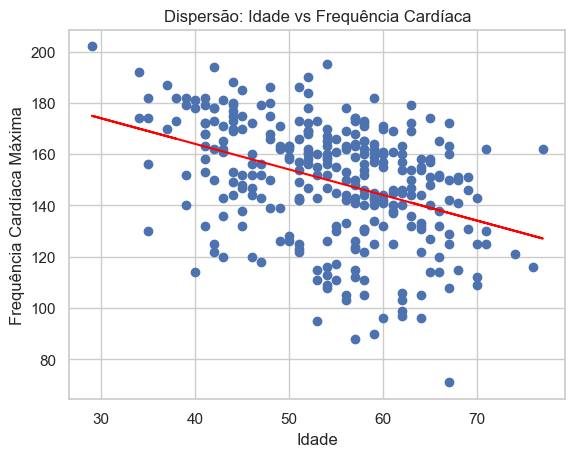

Coeficiente de Correlação Peso x Consumo: -0.39


In [86]:
plt.scatter(df["age"], df["thalach"])
z = np.polyfit(df["age"], df["thalach"], 1)
p = np.poly1d(z)
plt.plot (df["age"], p(df["age"]), color='red')
plt.title("Dispersão: Idade vs Frequência Cardíaca")
plt.xlabel("Idade")
plt.ylabel("Frequência Cardíaca Máxima")
plt.grid(True)
plt.show()

correlacao_mpg = df["age"].corr(df["thalach"])
print(f"Coeficiente de Correlação Peso x Consumo: {correlacao_mpg:.2f}")


<Axes: xlabel='age', ylabel='Count'>

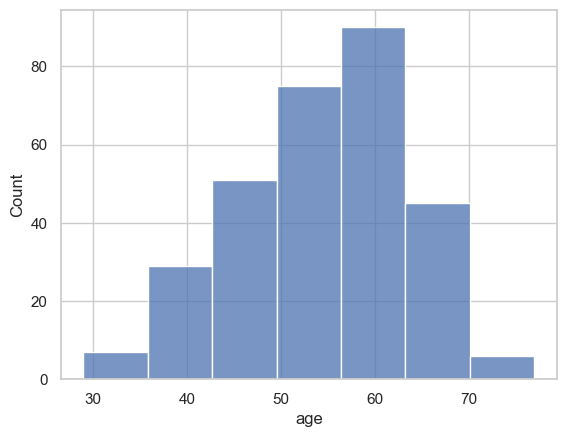

In [87]:
sns.histplot(df['age'], bins=h)

# Part Three

In [88]:
df_age_split = pd.DataFrame()
df_age_split['age_band'] = pd.cut(
    df['age'],
    bins=[30, 40, 50, 60, 70],
    labels=['30-39', '40-49', '50-59', '60-69'],
    right=False
)
df_age_split['target'] = df.target

fi = df_age_split.groupby('age_band')['target'].sum()
fi

age_band
30-39     4
40-49    22
50-59    60
60-69    49
Name: target, dtype: int64

In [89]:
pmf = fi / fi.sum()
pmf

age_band
30-39    0.029630
40-49    0.162963
50-59    0.444444
60-69    0.362963
Name: target, dtype: float64

In [90]:
cdf = pmf.cumsum()
cdf

age_band
30-39    0.029630
40-49    0.192593
50-59    0.637037
60-69    1.000000
Name: target, dtype: float64

In [91]:
expected = expected_val(fi, pmf)
var = variance(fi, pmf, expected)

print(f'E(Y) = {expected}')
print(f'Var(Y) = {var}')

E(Y) = 48.15555555555555
Var(Y) = 231.86469135802471


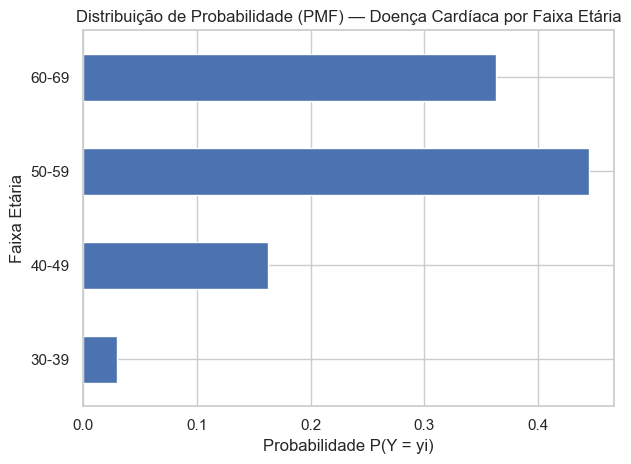

In [92]:
fig, ax = plt.subplots()
pmf.plot.barh(ax=ax)
ax.set_title('Distribuição de Probabilidade (PMF) — Doença Cardíaca por Faixa Etária')
ax.set_xlabel('Probabilidade P(Y = yi)')
ax.set_ylabel('Faixa Etária')
plt.tight_layout()
plt.show()

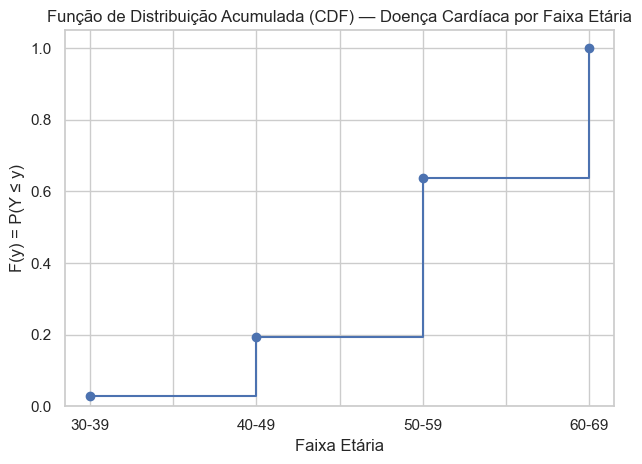

In [93]:
fig, ax = plt.subplots()
cdf.plot(drawstyle='steps-post', ax=ax, marker='o')
ax.set_title('Função de Distribuição Acumulada (CDF) — Doença Cardíaca por Faixa Etária')
ax.set_xlabel('Faixa Etária')
ax.set_ylabel('F(y) = P(Y ≤ y)')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Problema aplicado

Modelamos Y ~ Poisson, onde lambda = E(Y)

Justificativa: A distribuição de Poisson é adequada para contar eventos em um intervalo fixo, assumindo que cada caso ocorre de forma independente e com taxa média constante lambda.

In [99]:
from scipy.stats import poisson

p_bigger_40 = 1 - poisson.cdf(40, expected)
print(f'{p_bigger_40 * 100:.3f}%')

86.645%


# Part Four

# Part Five